In [2]:
import sys
sys.path.append('../../../../../src')
sys.path.append('../../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from image.processing import DITHER_MODES
from converters.tile.bin_2d import Tile2Symb2dBin

from tests.experimental.converters.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../../fonts/CascadiaMono.ttf"
FONT_SIZE = 11
IMG_SET_PATH = "../../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:5]]

def make_converter(params: Params):
    return Tile2Symb2dBin(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: 0.1139 | Max: 0.4131 | Mean: 0.2312 | Std: 0.1278
Min: 0.0949 | Max: 0.4212 | Mean: 0.2483 | Std: 0.1226
Min: 0.0753 | Max: 0.3464 | Mean: 0.2050 | Std: 0.1147
Min: 0.0485 | Max: 0.3451 | Mean: 0.1918 | Std: 0.0994
Min: 0.1125 | Max: 0.2101 | Mean: 0.1488 | Std: 0.0338
Min: 0.1156 | Max: 0.1791 | Mean: 0.1360 | Std: 0.0238
Min: 0.0199 | Max: 0.1706 | Mean: 0.0923 | Std: 0.0570
Min: 0.0701 | Max: 0.1074 | Mean: 0.0963 | Std: 0.0142
Min: 0.0662 | Max: 0.1092 | Mean: 0.0832 | Std: 0.0143
Min: 0.1128 | Max: 0.1382 | Mean: 0.1265 | Std: 0.0103
Min: 0.0897 | Max: 0.1705 | Mean: 0.1314 | Std: 0.0259


C:\Users\wojte\AppData\Local\Temp\ipykernel_12336\589972136.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


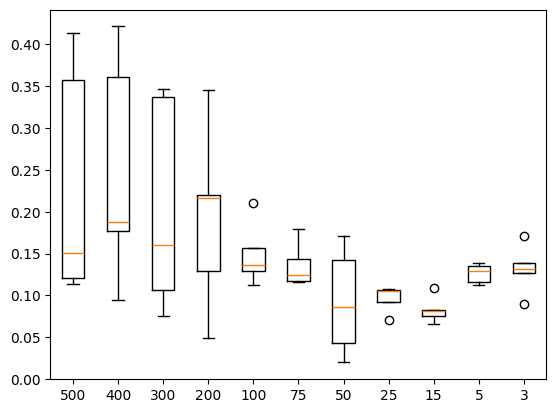

In [3]:
# window width

params_space = [
    w for w in range(500, 100, -100)
]
params_space += [
    w for w in range(100, 25, -25)
]
params_space += [
    w for w in range(25, 5, -10)
]
params_space += [
    w for w in range(5, 2, -2)
]

params_space = list(
    map(lambda w: Params(
        win_width=w,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.win_width for param in params_space])
plt.show()

Min: 0.0278 | Max: 0.0550 | Mean: 0.0396 | Std: 0.0092
Min: 0.0803 | Max: 0.0961 | Mean: 0.0907 | Std: 0.0054
Min: 0.0981 | Max: 0.1310 | Mean: 0.1125 | Std: 0.0114
Min: 0.1229 | Max: 0.1615 | Mean: 0.1364 | Std: 0.0139
Min: 0.0866 | Max: 0.1293 | Mean: 0.1083 | Std: 0.0147
Min: 0.1128 | Max: 0.1381 | Mean: 0.1260 | Std: 0.0103
Min: 0.1134 | Max: 0.1344 | Mean: 0.1227 | Std: 0.0087
Min: 0.1160 | Max: 0.1336 | Mean: 0.1246 | Std: 0.0065
Min: 0.1149 | Max: 0.1487 | Mean: 0.1331 | Std: 0.0137


C:\Users\wojte\AppData\Local\Temp\ipykernel_12336\2940076416.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


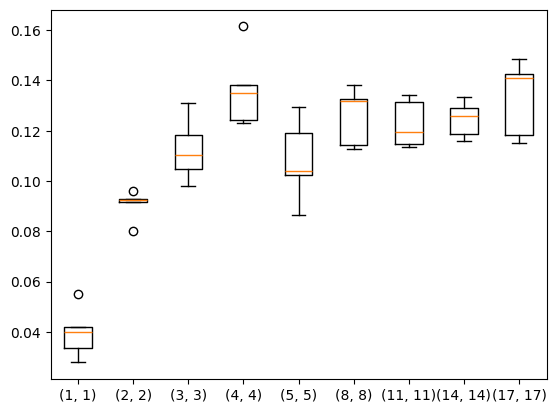

In [4]:
# bins

params_space = [
    (bins, bins) for bins in range(1, 5, 1)
]
params_space += [
    (bins, bins) for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: Params(
        win_width=5,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'bins': bins},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: 0.1128 | Max: 0.1403 | Mean: 0.1261 | Std: 0.0107
Min: 0.1124 | Max: 0.1354 | Mean: 0.1220 | Std: 0.0090
Min: 0.1110 | Max: 0.1364 | Mean: 0.1216 | Std: 0.0099


C:\Users\wojte\AppData\Local\Temp\ipykernel_12336\3146439082.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


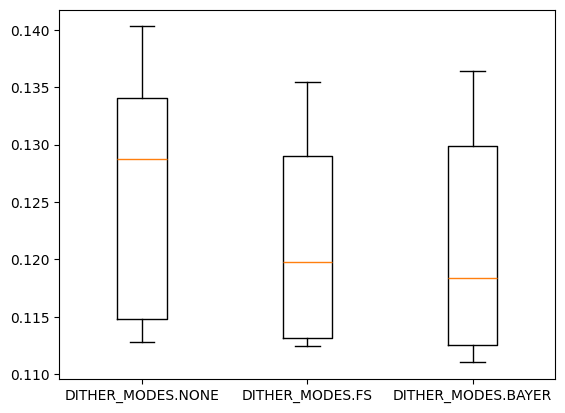

In [5]:
# dithering

params_space = [
    {'quantize_colors': 256, 'dither': DITHER_MODES.NONE},
    {'quantize_colors': 2, 'dither': DITHER_MODES.FS},
    {'quantize_colors': 2, 'dither': DITHER_MODES.BAYER}
]

params_space = list(
    map(lambda preprocess_args: Params(
        win_width=5,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['dither'] for param in params_space])
plt.show()

Min: 0.0717 | Max: 0.1024 | Mean: 0.0868 | Std: 0.0133
Min: 0.1002 | Max: 0.1259 | Mean: 0.1125 | Std: 0.0095
Min: 0.1516 | Max: 0.1917 | Mean: 0.1630 | Std: 0.0152
Min: 0.1689 | Max: 0.2313 | Mean: 0.1979 | Std: 0.0213
Min: 0.1771 | Max: 0.2929 | Mean: 0.2208 | Std: 0.0389


C:\Users\wojte\AppData\Local\Temp\ipykernel_12336\2570039073.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


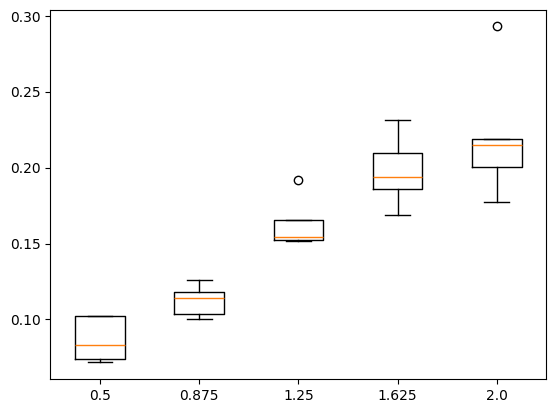

In [6]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        win_width=5,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()